In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys
import numpy as np
import pandas as pd

def find_repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "scripts" / "generate_finer_cam_panderm.py").exists():
            return p.resolve()
    raise FileNotFoundError


REPO = find_repo_root()
for extra in [REPO, REPO / "external" / "PanDerm" / "classification"]:
    if str(extra) not in sys.path:
        sys.path.insert(0, str(extra))

from src.thesis.config import *
from src.thesis import data, models, cams, metrics, plotting, audit

EV = data.load_eval()
LESION = data.load_lesions(EV)
QC = data.load_qc()
HUM = data.load_hum(QC, LESION)
X_TEST, Y_MEL, ID_TEST, TEST_DF = data.load_test()
M0, M5 = models.ck5("ha0"), models.ck5("ha5")

AUD = audit.run_audit(EV, LESION, HUM, X_TEST, Y_MEL, ID_TEST, QC, M0, M5)

                                       check  pass         detail
                            index convention  True               
                  test split 987 with 54 MEL  True       987 / 54
                  no annotated image in test  True               
                 lesion masks non degenerate  True             34
             HUM has positives and negatives  True             31
                          ha0 and ha5 differ  True               
                 target follows ground truth  True               
            FinerCAM alpha 0 equals Grad-CAM  True       1.000000
                          AUC rank invariant  True               
                          AUC argument order  True               
              HUM identical to 14d reference  True 31 ref, 31 new
            centre baseline reproduces 0.828  True          0.828
aligned target vs clinician reproduces 0.743  True          0.743

all 13 checks pass


                 mel_on_mel  nv_on_rest   corr   mass  dead
model     alpha                                            
aligned   0.0         0.025      -0.044  0.909  0.845     0
          0.2         0.021      -0.050  0.799  0.830     0
          0.4         0.012      -0.063  0.531  0.789     0
          0.6         0.003      -0.097 -0.110  0.618     2
          0.8        -0.011      -0.056 -0.481  0.340     5
          1.0        -0.061       0.002 -0.397  0.196     7
unaligned 0.0         0.082       0.086 -0.329  0.516     0
          0.2         0.063       0.078 -0.385  0.514     0
          0.4         0.047       0.081 -0.415  0.511     0
          0.6         0.044       0.085 -0.426  0.530     0
          0.8         0.042       0.082 -0.426  0.531     0
          1.0         0.044       0.083 -0.424  0.527     0
  unaligned alpha 0.2 vs 0  MEL map  -0.003  p 0.209
  unaligned alpha 0.4 vs 0  MEL map  -0.004  p 0.224
  unaligned alpha 0.6 vs 0  MEL map  -0.000  p 0.217
 

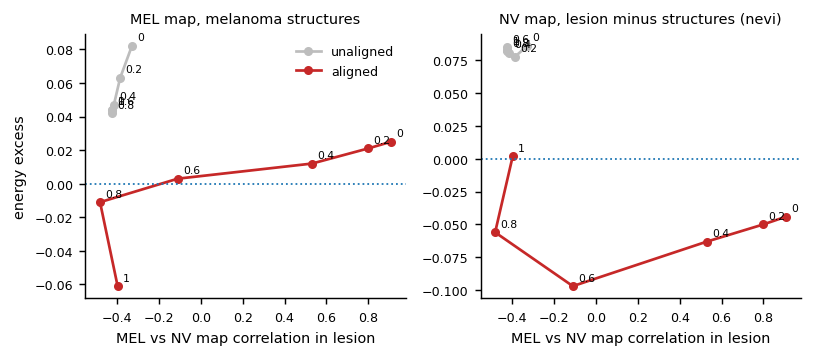


Pareto optimal alphas, aligned: [0.0, 0.2, 0.4, 0.6, 0.8]


In [2]:
import matplotlib.pyplot as plt

ALPHAS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
rows = []
for mname, m in [("unaligned", M0), ("aligned", M5)]:
    for iid in sorted(HUM):
        r = EV.loc[iid]
        x = data.to_tensor(data.native(r.image_rel_path))
        L, U = LESION[iid], HUM[iid]
        for a in ALPHAS:
            fm = cams.finer_cam(m, x, "MEL", a)
            fn = cams.finer_cam(m, x, "NV", a)
            dead = fm[L].max() < 1e-6
            rows.append({"model": mname, "alpha": a, "image_id": iid, "gt": r.gt_label,
                         "mel_on_mel": np.nan if dead else metrics.energy_excess(fm, L, U),
                         "nv_on_rest": (metrics.energy_excess(fn, L, L & ~U)
                                        if r.gt_label == "NV" and fn[L].max() > 1e-6 else np.nan),
                         "corr": metrics.corr_in(fm, fn, L),
                         "mel_mass_in_lesion": float(fm[L].sum() / (fm.sum() + 1e-8)),
                         "dead": dead})
FA = pd.DataFrame(rows)
FA.to_csv(TAB / "finercam_alpha_sweep.csv", index=False)

S = FA.groupby(["model", "alpha"]).agg(mel_on_mel=("mel_on_mel", "median"),
                                       nv_on_rest=("nv_on_rest", "median"),
                                       corr=("corr", "median"),
                                       mass=("mel_mass_in_lesion", "median"),
                                       dead=("dead", "sum")).round(3)
print(S.to_string())

for mname in ["unaligned", "aligned"]:
    q = FA[FA.model == mname].pivot_table(index="image_id", columns="alpha", values="mel_on_mel")
    for a in ALPHAS[1:]:
        res = metrics.paired(q[a], q[0.0])
        print(f"  {mname:9} alpha {a:.1f} vs 0  MEL map  {res['diff']:+.3f}  p {res['p']:.3f}")

def pareto(df):
    keep = []
    for i, r in df.iterrows():
        dom = ((df["corr"] <= r["corr"]) & (df.mel_on_mel >= r.mel_on_mel) &
               ((df["corr"] < r["corr"]) | (df.mel_on_mel > r.mel_on_mel))).any()
        keep.append(not dom)
    return df[keep]

fig, ax = plt.subplots(1, 2, figsize=(plotting.TEXTWIDTH, 2.8))
for j, (col, ttl) in enumerate([("mel_on_mel", "MEL map, melanoma structures"),
                               ("nv_on_rest", "NV map, lesion minus structures (nevi)")]):
    for mname, c in [("unaligned", plotting.C_CONTEXT), ("aligned", plotting.C_FOCUS)]:
        s = S.loc[mname]
        ax[j].plot(s["corr"], s[col], "o-", color=c, label=mname, lw=1.5, ms=4)
        for a in ALPHAS:
            ax[j].annotate(f"{a:g}", (s.loc[a, "corr"], s.loc[a, col]),
                           xytext=(3, 3), textcoords="offset points", fontsize=6)
    ax[j].axhline(0, color=plotting.C_REF, ls=":", lw=1)
    ax[j].set(xlabel="MEL vs NV map correlation in lesion", title=ttl)
ax[0].set_ylabel("energy excess")
ax[0].legend(frameon=False)
fig.tight_layout()
plotting.save(fig, "finercam_alpha_pareto")
plt.show()
print("\nPareto optimal alphas, aligned:", pareto(S.loc["aligned"].reset_index()).alpha.tolist())

In [3]:
def energy_grid(v, T):
    """Heat on target over ALL heat, minus target share of the full grid.
    Not conditional on the lesion. Reported as a complement, not a new primary."""
    v = metrics.norm01(v) if hasattr(metrics, "norm01") else cams.norm01(v)
    return float(v[T].sum() / (v.sum() + 1e-8) - T.mean())

rows = []
for mname, m in [("unaligned", M0), ("aligned", M5)]:
    for iid in sorted(HUM):
        r = EV.loc[iid]
        x = data.to_tensor(data.native(r.image_rel_path))
        L, U = LESION[iid], HUM[iid]
        mel, nv = cams.class_cams(m, x)
        rows.append({"model": mname, "image_id": iid, "gt": r.gt_label,
                     "in_lesion": metrics.energy_excess(mel, L, U),
                     "whole_grid": energy_grid(mel, U & L),
                     "auc_in": metrics.auc_in(mel, L, U),
                     "nv_in_lesion": (metrics.energy_excess(nv, L, L & ~U)
                                      if r.gt_label == "NV" else np.nan),
                     "nv_whole_grid": (energy_grid(nv, L & ~U)
                                       if r.gt_label == "NV" else np.nan)})
UA = pd.DataFrame(rows)
cols = ["in_lesion", "whole_grid", "auc_in", "nv_in_lesion", "nv_whole_grid"]
print(UA.groupby("model")[cols].median().round(3).to_string())
for c in cols:
    q = UA.pivot_table(index="image_id", columns="model", values=c)
    res = metrics.paired(q["aligned"], q["unaligned"])
    print(f"  aligned minus unaligned  {c:14} {res['diff']:+.3f}  p {res['p']:.3f}  n {res['n']}")

           in_lesion  whole_grid  auc_in  nv_in_lesion  nv_whole_grid
model                                                                
aligned        0.025       0.350   0.700        -0.044          0.145
unaligned      0.082       0.084   0.585         0.082         -0.012
  aligned minus unaligned  in_lesion      -0.031  p 0.073  n 31
  aligned minus unaligned  whole_grid     +0.233  p 0.000  n 31
  aligned minus unaligned  auc_in         +0.075  p 0.012  n 31
  aligned minus unaligned  nv_in_lesion   -0.126  p 0.039  n 16
  aligned minus unaligned  nv_whole_grid  +0.179  p 0.002  n 16
